# CLASSIFICATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
don = pd.read_csv("donclassif.txt", header=0, sep=";")
don.head()
print(don.shape)
print(don.describe)

(2800, 2)
<bound method NDFrame.describe of             V1        V2
0     6.002504  0.031505
1     6.004021  0.063168
2     6.004545  0.094957
3     6.004069  0.126843
4     6.002587  0.158794
...        ...       ...
2795  1.223519  5.870877
2796 -0.472344  4.910527
2797  0.961090  5.183866
2798  0.067021  5.228207
2799  0.138501  4.122749

[2800 rows x 2 columns]>


### /!\ Ne pas oublier de centrer et réduire les variables (pas fait ici car les 2 variables ont la même échelle)

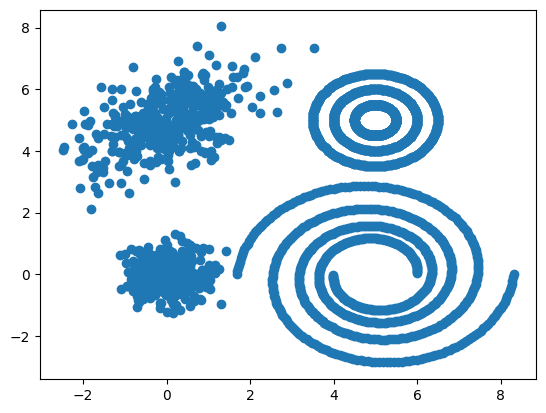

In [3]:
plt.plot(don["V1"],don["V2"],'o')
plt.show()

# K-means

In [4]:
from sklearn.cluster import KMeans
tmp = KMeans(n_clusters=6, n_init=1,init='random').fit(don)
pd.Series(tmp.labels_).value_counts()

4    1229
1     409
3     391
2     372
5     201
0     198
Name: count, dtype: int64

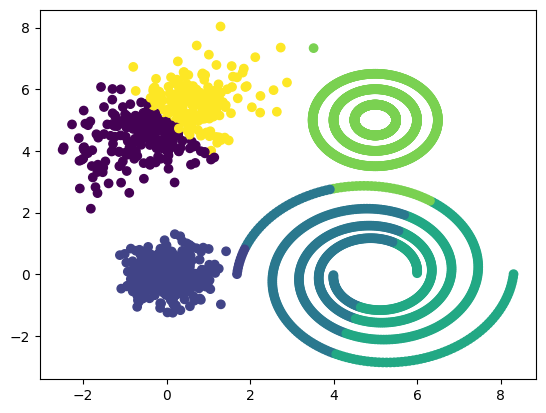

In [5]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.show()

0    695
2    575
3    410
5    394
1    373
4    353
Name: count, dtype: int64


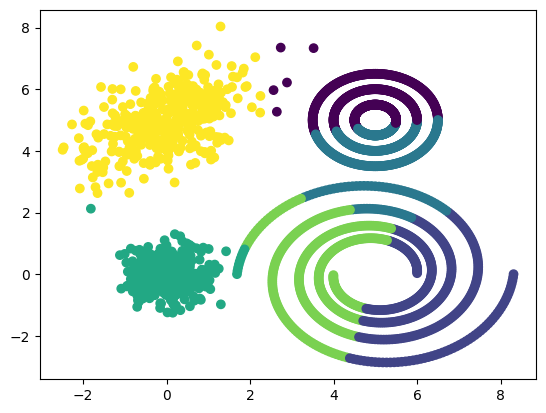

In [6]:
tmp = KMeans(n_clusters=6, n_init=1,init='random').fit(don)
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
print(pd.Series(tmp.labels_).value_counts())
plt.show()

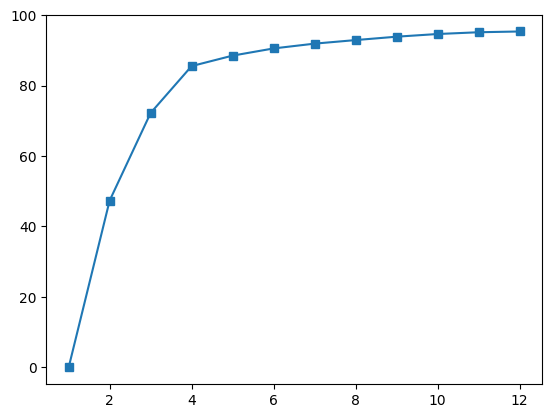

In [7]:
rapport = np.zeros(12)
inertietot = KMeans(n_clusters=1, n_init=10).fit(don)
inertietot = inertietot.inertia_
### car je ne sais pas retrouver l'inertie totale
for ii in range(1, 13):
    toto = KMeans(n_clusters=ii, n_init=10,init='random').fit(don)
    rapport[ii-1] = 100-round(toto.inertia_ / inertietot * 100, 2)
### je fais 100 moins pour avoir l'évolution croissante qui est à mon avis plus facile àlire
plt.plot(range(1, 13), rapport, marker='s')
plt.show()

je choisis 4 groupes

In [8]:
tmp = KMeans(n_clusters=4, n_init=100,init='random').fit(don)
pd.Series(tmp.labels_).value_counts()

0    1244
2     708
1     454
3     394
Name: count, dtype: int64

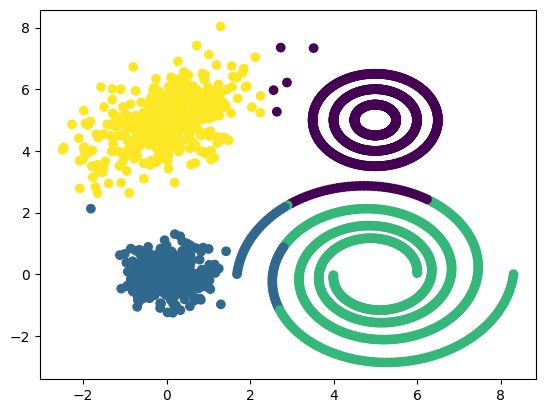

In [9]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.show()

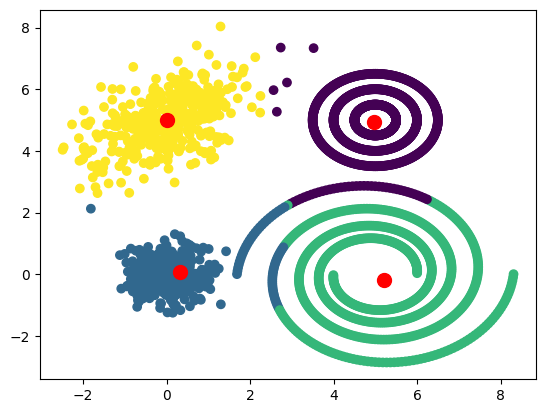

In [10]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.scatter(tmp.cluster_centers_[:,0],tmp.cluster_centers_[:,1], color="red", s=100)
plt.show()

# classification hiérarchique

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage

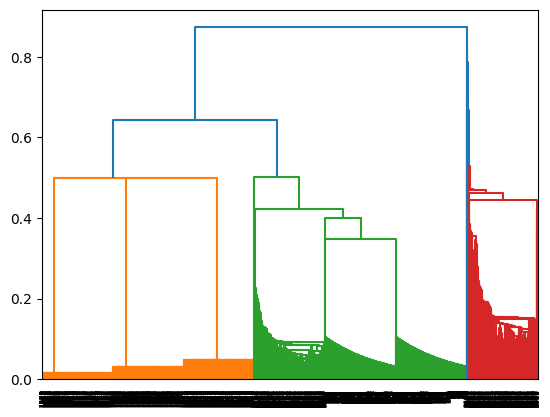

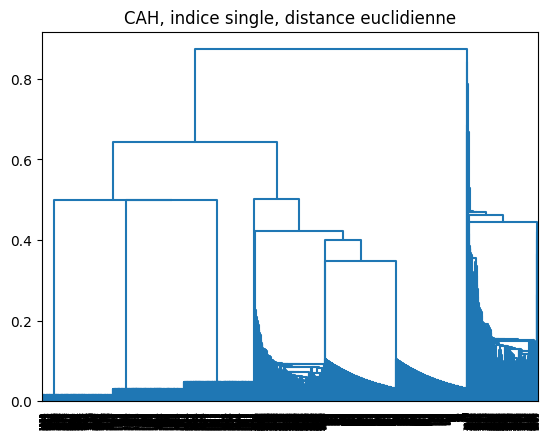

In [12]:
### choix du lien et de la distance
hiera_def = linkage(don)
dendrogram(hiera_def,labels=don.index)
plt.show()
hiera_sin = linkage(don,method="single")
plt.title("CAH, indice single, distance euclidienne")
dendrogram(hiera_sin,labels=don.index,color_threshold=0)
plt.show()

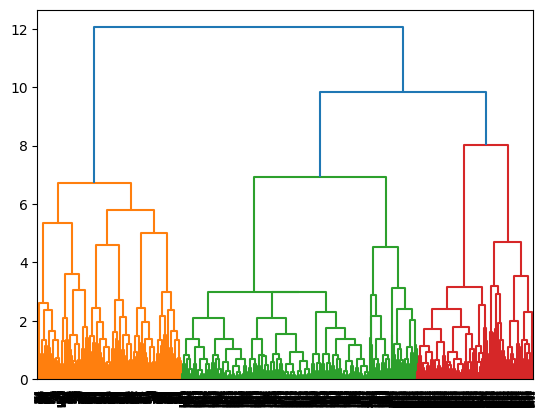

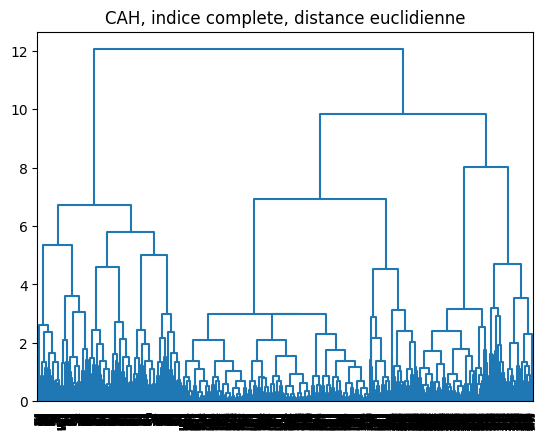

In [13]:
### choix du lien et de la distance
hiera_com = linkage(don,method='complete')
dendrogram(hiera_com,labels=don.index)
plt.show()
plt.title("CAH, indice complete, distance euclidienne")
dendrogram(hiera_com,labels=don.index,color_threshold=0)
plt.show()

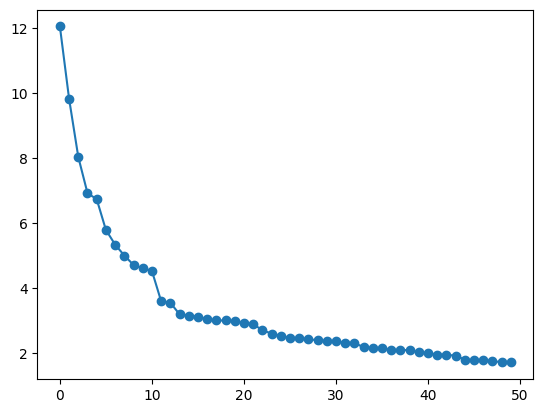

In [14]:
heights = np.sort(hiera_com[:,2])[::-1]
plt.plot(heights[:50], marker="o")

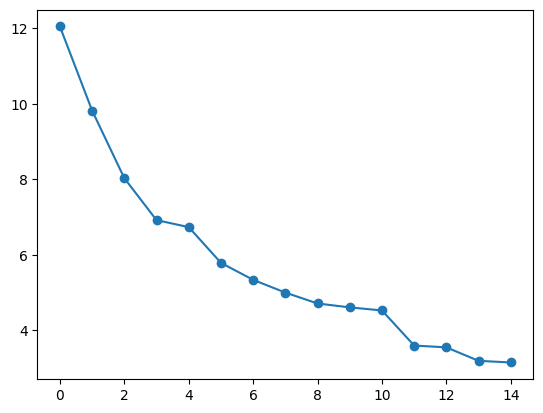

In [15]:
plt.plot(heights[:15], marker="o")

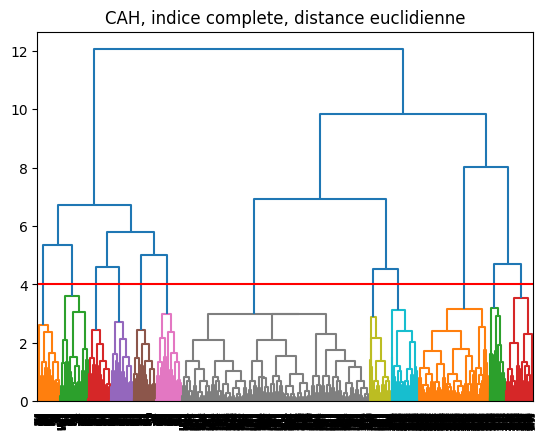

In [19]:
plt.title("CAH, indice complete, distance euclidienne")
dendrogram(hiera_com,labels=don.index,color_threshold=4)   # color_threshold : définir la valeur sur le dendrogramme où on veut couper
plt.axhline(y=4, color="red")
plt.show()

# CAH sur centres issus du K-means
avec données volumineuses

In [20]:
don = pd.read_csv("donclassif2.txt", header=0, sep=";")
don.head()
print(don.shape)
print(don.describe)

(70000, 2)
<bound method NDFrame.describe of              V1        V2
0      5.971089 -0.027773
1      6.035601  0.037879
2      5.968887 -0.027694
3      5.953036 -0.042402
4      6.034341  0.040049
...         ...       ...
69995 -0.566215  4.344230
69996  1.934682  5.194582
69997 -0.167337  5.744387
69998  1.216668  5.184842
69999  0.113974  5.575859

[70000 rows x 2 columns]>


On lance un k-means pour réduire le nombre de lignes et on récupère les centres de classes

In [21]:
from sklearn.cluster import KMeans
tmp = KMeans(n_clusters=5000, n_init=1,init='random').fit(don)
pd.Series(tmp.labels_).value_counts()

1598    42
676     38
592     37
2362    36
455     35
        ..
1080     1
1983     1
2380     1
708      1
585      1
Name: count, Length: 5000, dtype: int64

In [ ]:
tmp.cluster_centers_

array([[ 4.65771988, -1.02276786],
       [ 4.83152676,  1.57128071],
       [ 5.66564237,  5.75081425],
       ...,
       [ 2.37322575,  6.95703896],
       [ 5.46060556,  5.19452951],
       [ 5.01225202,  3.50005626]], shape=(5000, 2))